# Election Bloc Change Prediction Project
## Notebook 01 — Clean loading and party-to-bloc mapping, Knesset 16–25

This is a clean rebuild of Notebook 01.

**Trusted input:** only the raw election files under `data/raw/Election_data`.

The notebook:

1. downloads a fresh copy of the GitHub repository into Colab;
2. reads Knesset elections 16–25;
3. aggregates ballot-level files to locality level;
4. reconstructs locality symbols for Knesset 17;
5. excludes special-envelope rows;
6. applies an election-specific party-to-bloc mapping;
7. audits unmapped parties and vote arithmetic;
8. creates a clean locality-by-election dataset;
9. saves all outputs and downloads a verified ZIP.

The four modeled blocs are:

- `Right`
- `Center_Left`
- `Haredi`
- `Arab`

Votes outside those four mappings remain in `Other`.

## 0. Fresh repository clone and folders

In [1]:
from pathlib import Path
from zipfile import ZipFile, ZIP_DEFLATED
import importlib.util
import json
import re
import shutil
import subprocess
import sys
import time
import unicodedata

# Install the two Excel readers only when they are missing.
packages = {
    "xlrd": "xlrd==2.0.1",
    "openpyxl": "openpyxl",
}

missing_packages = [
    pip_name
    for module_name, pip_name in packages.items()
    if importlib.util.find_spec(module_name) is None
]

if missing_packages:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", *missing_packages],
        check=True,
    )

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 280)
pd.set_option("display.max_rows", 200)

REPO_URL = "https://github.com/IfatDav/Election_Bloc_Prediction_Project.git"
REPO_ROOT = Path("/content/Election_Bloc_Prediction_Project")

# Delete only the temporary Colab copy, never the GitHub repository.
if REPO_ROOT.exists():
    shutil.rmtree(REPO_ROOT)

print("Cloning the latest GitHub repository...")

subprocess.run(
    [
        "git",
        "clone",
        "--depth",
        "1",
        REPO_URL,
        str(REPO_ROOT),
    ],
    check=True,
)

RAW_DIR = REPO_ROOT / "data" / "raw"
ELECTION_DIR = RAW_DIR / "Election_data"

INTERIM_DIR = REPO_ROOT / "data" / "interim"
TABLES_DIR = REPO_ROOT / "reports" / "tables"
FIGURES_DIR = REPO_ROOT / "reports" / "figures"
SUMMARIES_DIR = REPO_ROOT / "reports" / "summaries"

for directory in [
    INTERIM_DIR,
    TABLES_DIR,
    FIGURES_DIR,
    SUMMARIES_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

if not ELECTION_DIR.exists():
    raise FileNotFoundError(
        f"Election directory was not found after cloning: {ELECTION_DIR}"
    )

MODELED_BLOCS = [
    "Right",
    "Center_Left",
    "Haredi",
    "Arab",
]

UNMAPPED_PARTY_STOP_THRESHOLD_PCT = 2.0
MINIMUM_TOTAL_MAPPING_COVERAGE_PCT = 90.0

print("Repository root:", REPO_ROOT)
print("Election directory:", ELECTION_DIR)

Cloning the latest GitHub repository...
Repository root: /content/Election_Bloc_Prediction_Project
Election directory: /content/Election_Bloc_Prediction_Project/data/raw/Election_data


## 1. Required raw election files

In [2]:
ELECTION_FILES = {
    16: "Knesset_16_Election_Results_2003_By_Kalfi.csv.xls",
    17: "Knesset_17_Election_Results_2006_By_Kalfi.csv.xls",
    18: "Knesset_18_Election_Results_2009_By_Kalfi.csv.csv",
    19: "Knesset_19_Election_Results_2013_By_Locality.csv.csv",
    20: "Knesset_20_Election_Results_2015_By_Locality.csv.csv",
    21: "Knesset_21_Election_Results_2019_By_Locality.csv",
    22: "Knesset_22_Election_Results_2019_By_Locality.csv",
    23: "Knesset_23_Election_Results_2020_By_Locality.csv",
    24: "Knesset_24_Election_Results_2021_By_Locality.csv",
    25: "Knesset_25_Election_Results_2022_By_Locality.csv",
}

ELECTION_YEARS = {
    16: 2003,
    17: 2006,
    18: 2009,
    19: 2013,
    20: 2015,
    21: 2019,
    22: 2019,
    23: 2020,
    24: 2021,
    25: 2022,
}

source_inventory_rows = []

for election_number, filename in ELECTION_FILES.items():
    path = ELECTION_DIR / filename

    source_inventory_rows.append({
        "election_number": election_number,
        "target_election": f"Knesset_{election_number}",
        "year": ELECTION_YEARS[election_number],
        "filename": filename,
        "relative_path": str(path.relative_to(REPO_ROOT)),
        "exists": path.exists(),
        "size_bytes": path.stat().st_size if path.exists() else 0,
    })

election_source_inventory = pd.DataFrame(source_inventory_rows)

display(election_source_inventory)

missing_files = election_source_inventory.loc[
    ~election_source_inventory["exists"],
    "relative_path",
].tolist()

empty_files = election_source_inventory.loc[
    election_source_inventory["size_bytes"].le(0),
    "relative_path",
].tolist()

if missing_files:
    raise FileNotFoundError(
        "The following required election files are missing:\n- "
        + "\n- ".join(missing_files)
    )

if empty_files:
    raise RuntimeError(
        "The following election files are empty:\n- "
        + "\n- ".join(empty_files)
    )

print("All ten raw election files are present and non-empty.")

,election_number,target_election,year,filename,relative_path,exists,size_bytes
0,16,Knesset_16,2003,Knesset_16_Election_Results_2003_By_Kalfi.csv.xls,data/raw/Election_data/Knesset_16_Election_Res...,True,2118656
1,17,Knesset_17,2006,Knesset_17_Election_Results_2006_By_Kalfi.csv.xls,data/raw/Election_data/Knesset_17_Election_Res...,True,2420224
2,18,Knesset_18,2009,Knesset_18_Election_Results_2009_By_Kalfi.csv.csv,data/raw/Election_data/Knesset_18_Election_Res...,True,1134138
3,19,Knesset_19,2013,Knesset_19_Election_Results_2013_By_Locality.c...,data/raw/Election_data/Knesset_19_Election_Res...,True,133786
4,20,Knesset_20,2015,Knesset_20_Election_Results_2015_By_Locality.c...,data/raw/Election_data/Knesset_20_Election_Res...,True,106836
5,21,Knesset_21,2019,Knesset_21_Election_Results_2019_By_Locality.csv,data/raw/Election_data/Knesset_21_Election_Res...,True,150776
6,22,Knesset_22,2019,Knesset_22_Election_Results_2019_By_Locality.csv,data/raw/Election_data/Knesset_22_Election_Res...,True,125654
7,23,Knesset_23,2020,Knesset_23_Election_Results_2020_By_Locality.csv,data/raw/Election_data/Knesset_23_Election_Res...,True,120101
8,24,Knesset_24,2021,Knesset_24_Election_Results_2021_By_Locality.csv,data/raw/Election_data/Knesset_24_Election_Res...,True,145731
9,25,Knesset_25,2022,Knesset_25_Election_Results_2022_By_Locality.csv,data/raw/Election_data/Knesset_25_Election_Res...,True,154331


All ten raw election files are present and non-empty.


## 2. Robust readers

In [3]:
def clean_column_name(value):
    return re.sub(
        r"\s+",
        " ",
        str(value).replace("\ufeff", "").strip(),
    )


def numeric_series(series):
    return pd.to_numeric(
        (
            series.astype("string")
            .str.replace(",", "", regex=False)
            .str.strip()
        ),
        errors="coerce",
    )


def first_existing_column(dataframe, candidates, required=True):
    for candidate in candidates:
        if candidate in dataframe.columns:
            return candidate

    if required:
        raise KeyError(
            f"None of the expected columns were found: {candidates}"
        )

    return None


def read_election_file(path):
    if path.name.endswith(".xls"):
        dataframe = pd.read_excel(path, engine="xlrd")
        reader = "xlrd"

    else:
        dataframe = None
        reader = None
        errors = []

        for encoding in [
            "utf-8-sig",
            "utf-8",
            "cp1255",
            "iso-8859-8",
        ]:
            try:
                dataframe = pd.read_csv(
                    path,
                    encoding=encoding,
                    low_memory=False,
                )
                reader = encoding
                break
            except UnicodeDecodeError as error:
                errors.append(f"{encoding}: {error}")

        if dataframe is None:
            raise UnicodeError(
                f"Could not decode {path}.\n" + "\n".join(errors)
            )

    dataframe.columns = [
        clean_column_name(column)
        for column in dataframe.columns
    ]

    columns_to_drop = [
        column
        for column in dataframe.columns
        if not column
        or column.lower().startswith("unnamed")
    ]

    if columns_to_drop:
        dataframe = dataframe.drop(columns=columns_to_drop)

    return dataframe, reader


raw_elections = {}
read_audit_rows = []

for election_number, filename in ELECTION_FILES.items():
    path = ELECTION_DIR / filename
    dataframe, reader = read_election_file(path)

    raw_elections[election_number] = dataframe

    read_audit_rows.append({
        "election_number": election_number,
        "target_election": f"Knesset_{election_number}",
        "reader": reader,
        "raw_rows": len(dataframe),
        "raw_columns": dataframe.shape[1],
    })

raw_election_read_audit = pd.DataFrame(read_audit_rows)

display(raw_election_read_audit)

print("Raw elections loaded:", sorted(raw_elections.keys()))

if sorted(raw_elections.keys()) != list(range(16, 26)):
    raise RuntimeError("Not all elections 16–25 were loaded into memory.")

,election_number,target_election,reader,raw_rows,raw_columns
0,16,Knesset_16,xlrd,7886,35
1,17,Knesset_17,xlrd,8426,36
2,18,Knesset_18,cp1255,9264,42
3,19,Knesset_19,utf-8-sig,1184,40
4,20,Knesset_20,cp1255,1196,32
5,21,Knesset_21,cp1255,1214,49
6,22,Knesset_22,cp1255,1214,39
7,23,Knesset_23,cp1255,1214,37
8,24,Knesset_24,cp1255,1215,46
9,25,Knesset_25,utf-8-sig,1216,47


Raw elections loaded: [16, 17, 18, 19, 20, 21, 22, 23, 24, 25]


## 3. Locality crosswalk for Knesset 17

In [4]:
LOCALITY_SYMBOL_CANDIDATES = [
    "סמל ישוב",
    "סמל יישוב",
    "סמל היישוב",
]

LOCALITY_NAME_CANDIDATES = [
    "שם ישוב",
    "שם יישוב",
    "שם היישוב",
]

SPECIAL_ENVELOPE_PATTERN = r"מעטפות|כפולות|חיצוניות"


def normalize_locality_name(value):
    if pd.isna(value):
        return pd.NA

    text = unicodedata.normalize("NFKC", str(value))

    text = (
        text
        .replace("׳", "'")
        .replace("״", '"')
        .replace("־", "-")
    )

    text = re.sub(
        r"""[\(\)\[\]\{\}'".,]""",
        " ",
        text,
    )

    text = re.sub(r"\s*-\s*", "-", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text


# Build a historical reference from every election that contains symbols.
reference_frames = []

for election_number, dataframe in raw_elections.items():
    symbol_column = first_existing_column(
        dataframe,
        LOCALITY_SYMBOL_CANDIDATES,
        required=False,
    )

    name_column = first_existing_column(
        dataframe,
        LOCALITY_NAME_CANDIDATES,
        required=False,
    )

    if symbol_column is None or name_column is None:
        continue

    reference = pd.DataFrame({
        "locality_symbol": numeric_series(
            dataframe[symbol_column]
        ).astype("Int64"),
        "locality_name": (
            dataframe[name_column]
            .astype("string")
            .str.strip()
        ),
        "source_election_number": election_number,
    })

    reference = reference.loc[
        reference["locality_symbol"].gt(0)
        & reference["locality_symbol"].ne(9999)
        & reference["locality_name"].notna()
    ].copy()

    reference["normalized_name"] = reference[
        "locality_name"
    ].map(normalize_locality_name)

    reference_frames.append(reference)

locality_reference = (
    pd.concat(reference_frames, ignore_index=True)
    .drop_duplicates()
)

symbol_candidates_by_name = (
    locality_reference
    .groupby("normalized_name")["locality_symbol"]
    .agg(
        lambda values: sorted({
            int(value)
            for value in values.dropna()
        })
    )
)

unique_name_to_symbol = {
    normalized_name: symbols[0]
    for normalized_name, symbols
    in symbol_candidates_by_name.items()
    if len(symbols) == 1
}

# Three historical names require an explicit, documented alias.
MANUAL_K17_ALIASES = {
    normalize_locality_name("יהוד-נווה אפרים"): 9400,
    normalize_locality_name("סוואעד חמיירה"): 942,
    normalize_locality_name("צורן-קדימה"): 195,
}


def attach_locality_identity(dataframe):
    symbol_column = first_existing_column(
        dataframe,
        LOCALITY_SYMBOL_CANDIDATES,
        required=False,
    )

    name_column = first_existing_column(
        dataframe,
        LOCALITY_NAME_CANDIDATES,
        required=True,
    )

    names = (
        dataframe[name_column]
        .astype("string")
        .str.strip()
    )

    normalized_names = names.map(normalize_locality_name)

    if symbol_column is not None:
        symbols = numeric_series(
            dataframe[symbol_column]
        ).astype("Int64")

        methods = pd.Series(
            "source_symbol",
            index=dataframe.index,
            dtype="string",
        )

    else:
        automatic_symbols = normalized_names.map(
            unique_name_to_symbol
        )

        manual_symbols = normalized_names.map(
            MANUAL_K17_ALIASES
        )

        symbols = (
            automatic_symbols
            .fillna(manual_symbols)
            .astype("Int64")
        )

        methods = pd.Series(
            np.where(
                normalized_names.isin(MANUAL_K17_ALIASES),
                "manual_alias",
                np.where(
                    automatic_symbols.notna(),
                    "normalized_unique_name",
                    "unresolved",
                ),
            ),
            index=dataframe.index,
            dtype="string",
        )

    return symbols, names, normalized_names, methods


(
    k17_symbols,
    k17_names,
    k17_normalized_names,
    k17_match_methods,
) = attach_locality_identity(raw_elections[17])

k17_special_mask = (
    k17_names
    .fillna("")
    .str.contains(
        SPECIAL_ENVELOPE_PATTERN,
        regex=True,
    )
)

unresolved_regular_k17 = sorted(
    k17_names.loc[
        k17_symbols.isna()
        & ~k17_special_mask
        & k17_names.notna()
    ]
    .astype(str)
    .unique()
    .tolist()
)

k17_locality_crosswalk_audit = (
    pd.DataFrame({
        "original_name": k17_names,
        "normalized_name": k17_normalized_names,
        "locality_symbol": k17_symbols,
        "match_method": k17_match_methods,
    })
    .groupby(
        [
            "original_name",
            "normalized_name",
            "locality_symbol",
            "match_method",
        ],
        dropna=False,
        as_index=False,
    )
    .size()
    .rename(columns={"size": "source_rows"})
)

display(
    k17_locality_crosswalk_audit[
        "match_method"
    ]
    .value_counts(dropna=False)
    .rename("rows")
    .to_frame()
)

if unresolved_regular_k17:
    raise ValueError(
        "Unresolved regular Knesset 17 localities:\n- "
        + "\n- ".join(unresolved_regular_k17)
    )

print("Knesset 17 crosswalk completed without unresolved regular localities.")

,rows
match_method,
normalized_unique_name,1146
manual_alias,3
unresolved,1


Knesset 17 crosswalk completed without unresolved regular localities.


## 4. Election-specific party-to-bloc mapping

In [5]:
mapping_rows = []


def add_mapping(election_number, bloc, party_rows, note=""):
    for ballot_letter, party_name in party_rows:
        mapping_rows.append({
            "election_number": election_number,
            "target_election": f"Knesset_{election_number}",
            "ballot_letter": ballot_letter,
            "party_name": party_name,
            "bloc": bloc,
            "mapping_note": note,
        })


# Knesset 16
add_mapping(16, "Right", [
    ("מחל", "Likud"),
    ("ב", "National Religious Party"),
    ("ל", "National Union"),
    ("כן", "Yisrael BaAliyah"),
    ("נץ", "Herut"),
])
add_mapping(16, "Center_Left", [
    ("אמת", "Labor–Meimad"),
    ("יש", "Shinui"),
    ("מרצ", "Meretz"),
    ("ם", "One Nation"),
])
add_mapping(16, "Haredi", [
    ("שס", "Shas"),
    ("ג", "United Torah Judaism"),
])
add_mapping(16, "Arab", [
    ("ו", "Hadash"),
    ("ד", "Balad"),
    ("עם", "United Arab List"),
])

# Knesset 17
add_mapping(17, "Right", [
    ("מחל", "Likud"),
    ("טב", "National Union–NRP"),
    ("כ", "Jewish National Front"),
    ("נץ", "Herut"),
])
add_mapping(17, "Center_Left", [
    ("כן", "Kadima"),
    ("אמת", "Labor–Meimad"),
    ("מרצ", "Meretz–Yachad"),
    ("זך", "Gil Pensioners"),
    ("חץ", "Hetz"),
    ("יש", "Shinui"),
    ("ל", "Yisrael Beiteinu"),
], note="Yisrael Beiteinu follows the fixed project mapping policy.")
add_mapping(17, "Haredi", [
    ("שס", "Shas"),
    ("ג", "United Torah Judaism"),
])
add_mapping(17, "Arab", [
    ("עם", "United Arab List–Ta'al"),
    ("ו", "Hadash"),
    ("ד", "Balad"),
    ("קפ", "Arab National Party"),
    ("ק", "Da'am"),
])

# Knesset 18
add_mapping(18, "Right", [
    ("מחל", "Likud"),
    ("ט", "National Union"),
    ("ב", "Jewish Home"),
])
add_mapping(18, "Center_Left", [
    ("כן", "Kadima"),
    ("אמת", "Labor"),
    ("מרצ", "Meretz"),
    ("ל", "Yisrael Beiteinu"),
    ("זך", "Gil Pensioners"),
], note="Yisrael Beiteinu follows the fixed project mapping policy.")
add_mapping(18, "Haredi", [
    ("שס", "Shas"),
    ("ג", "United Torah Judaism"),
])
add_mapping(18, "Arab", [
    ("עם", "United Arab List–Ta'al"),
    ("ו", "Hadash"),
    ("ד", "Balad"),
    ("ק", "Da'am"),
])

# Knesset 19
add_mapping(19, "Right", [
    ("מחל", "Likud–Yisrael Beiteinu"),
    ("טב", "Jewish Home"),
    ("נץ", "Otzma LeYisrael"),
])
add_mapping(19, "Center_Left", [
    ("פה", "Yesh Atid"),
    ("אמת", "Labor"),
    ("צפ", "Hatnua"),
    ("מרץ", "Meretz"),
    ("כן", "Kadima"),
])
add_mapping(19, "Haredi", [
    ("שס", "Shas"),
    ("ג", "United Torah Judaism"),
    ("ץ", "Am Shalem"),
    ("פז", "Koach Lehashpia"),
])
add_mapping(19, "Arab", [
    ("עם", "United Arab List–Ta'al"),
    ("ו", "Hadash"),
    ("ד", "Balad"),
    ("ק", "Da'am"),
])

# Knesset 20
add_mapping(20, "Right", [
    ("מחל", "Likud"),
    ("כ", "Kulanu"),
    ("טב", "Jewish Home"),
    ("קץ", "Yachad"),
])
add_mapping(20, "Center_Left", [
    ("אמת", "Zionist Union"),
    ("פה", "Yesh Atid"),
    ("מרצ", "Meretz"),
    ("ל", "Yisrael Beiteinu"),
], note="Yisrael Beiteinu follows the fixed project mapping policy.")
add_mapping(20, "Haredi", [
    ("שס", "Shas"),
    ("ג", "United Torah Judaism"),
])
add_mapping(20, "Arab", [
    ("ודעם", "Joint List"),
])

# Knesset 21
add_mapping(21, "Right", [
    ("מחל", "Likud"),
    ("טב", "Union of Right-Wing Parties"),
    ("כ", "Kulanu"),
    ("נ", "New Right"),
    ("ז", "Zehut"),
])
add_mapping(21, "Center_Left", [
    ("פה", "Blue and White"),
    ("אמת", "Labor"),
    ("מרצ", "Meretz"),
    ("נר", "Gesher"),
    ("ל", "Yisrael Beiteinu"),
], note="Yisrael Beiteinu follows the fixed project mapping policy.")
add_mapping(21, "Haredi", [
    ("שס", "Shas"),
    ("ג", "United Torah Judaism"),
])
add_mapping(21, "Arab", [
    ("ום", "Hadash–Ta'al"),
    ("דעם", "Ra'am–Balad"),
])

# Knesset 22
add_mapping(22, "Right", [
    ("מחל", "Likud"),
    ("טב", "Yamina"),
    ("כף", "Otzma Yehudit"),
])
add_mapping(22, "Center_Left", [
    ("פה", "Blue and White"),
    ("אמת", "Labor–Gesher"),
    ("מרצ", "Democratic Union"),
    ("ל", "Yisrael Beiteinu"),
], note="Yisrael Beiteinu follows the fixed project mapping policy.")
add_mapping(22, "Haredi", [
    ("שס", "Shas"),
    ("ג", "United Torah Judaism"),
])
add_mapping(22, "Arab", [
    ("ודעם", "Joint List"),
])

# Knesset 23
add_mapping(23, "Right", [
    ("מחל", "Likud"),
    ("טב", "Yamina"),
    ("נץ", "Otzma Yehudit"),
])
add_mapping(23, "Center_Left", [
    ("פה", "Blue and White"),
    ("אמת", "Labor–Gesher–Meretz"),
    ("ל", "Yisrael Beiteinu"),
], note="Yisrael Beiteinu follows the fixed project mapping policy.")
add_mapping(23, "Haredi", [
    ("שס", "Shas"),
    ("ג", "United Torah Judaism"),
])
add_mapping(23, "Arab", [
    ("ודעם", "Joint List"),
])

# Knesset 24
add_mapping(24, "Right", [
    ("מחל", "Likud"),
    ("ב", "Yamina"),
    ("ט", "Religious Zionism"),
    ("ת", "New Hope"),
])
add_mapping(24, "Center_Left", [
    ("פה", "Yesh Atid"),
    ("אמת", "Labor"),
    ("מרצ", "Meretz"),
    ("כן", "Blue and White"),
    ("ל", "Yisrael Beiteinu"),
], note="Yisrael Beiteinu follows the fixed project mapping policy.")
add_mapping(24, "Haredi", [
    ("שס", "Shas"),
    ("ג", "United Torah Judaism"),
])
add_mapping(24, "Arab", [
    ("ודעם", "Joint List"),
    ("עם", "Ra'am"),
])

# Knesset 25
add_mapping(25, "Right", [
    ("מחל", "Likud"),
    ("ב", "Jewish Home"),
    ("ט", "Religious Zionism–Otzma Yehudit"),
])
add_mapping(25, "Center_Left", [
    ("פה", "Yesh Atid"),
    ("אמת", "Labor"),
    ("מרצ", "Meretz"),
    ("כן", "National Unity"),
    ("ל", "Yisrael Beiteinu"),
], note="Yisrael Beiteinu follows the fixed project mapping policy.")
add_mapping(25, "Haredi", [
    ("שס", "Shas"),
    ("ג", "United Torah Judaism"),
])
add_mapping(25, "Arab", [
    ("עם", "Ra'am"),
    ("ום", "Hadash–Ta'al"),
    ("ד", "Balad"),
])

party_mapping = (
    pd.DataFrame(mapping_rows)
    .sort_values([
        "election_number",
        "bloc",
        "ballot_letter",
    ])
    .reset_index(drop=True)
)

duplicate_mapping = party_mapping.loc[
    party_mapping.duplicated(
        ["election_number", "ballot_letter"],
        keep=False,
    )
]

if not duplicate_mapping.empty:
    raise ValueError(
        "Duplicate election-letter mappings:\n"
        + duplicate_mapping.to_string(index=False)
    )

if sorted(party_mapping["election_number"].unique()) != list(range(16, 26)):
    raise ValueError("Party mapping is incomplete for elections 16–25.")

display(
    party_mapping.groupby(
        ["election_number", "bloc"]
    ).size().unstack(fill_value=0)
)

bloc,Arab,Center_Left,Haredi,Right
election_number,,,,
16,3,4,2,5
17,5,7,2,4
18,4,5,2,3
19,4,5,4,3
20,1,4,2,4
21,2,5,2,5
22,1,4,2,3
23,1,3,2,3
24,2,5,2,4


## 5. Aggregate each election to locality level

In [6]:
NON_PARTY_COLUMNS = {
    "סמל ועדה",
    "שם ישוב",
    "שם יישוב",
    "שם היישוב",
    "סמל ישוב",
    "סמל יישוב",
    "סמל היישוב",
    "סמל קלפי",
    "מספר קלפי",
    "כתובת",
    "בוחרים",
    "בזב",
    "בז''ב",
    'בז"ב',
    "מצביעים",
    "פסולים",
    "כשרים",
    "ריכוז",
    "שופט",
    "ברזל",
    "ת. עדכון",
}

BALLOT_COLUMN_CANDIDATES = [
    "סמל קלפי",
    "מספר קלפי",
]

ELIGIBLE_COLUMN_CANDIDATES = [
    "בזב",
    "בז''ב",
    'בז"ב',
    "בוחרים",
]

VOTES_CAST_COLUMN_CANDIDATES = ["מצביעים"]
INVALID_COLUMN_CANDIDATES = ["פסולים"]
VALID_COLUMN_CANDIDATES = ["כשרים"]


def identify_party_columns(dataframe):
    party_columns = []

    for column in dataframe.columns:
        if column in NON_PARTY_COLUMNS:
            continue

        if not column or column.lower().startswith("unnamed"):
            continue

        if numeric_series(dataframe[column]).notna().any():
            party_columns.append(column)

    return party_columns


def optional_numeric_column(dataframe, candidates):
    column = first_existing_column(
        dataframe,
        candidates,
        required=False,
    )

    if column is None:
        return pd.Series(
            np.nan,
            index=dataframe.index,
            dtype="float64",
        )

    return numeric_series(dataframe[column])


def first_non_missing(series):
    values = series.dropna()

    if values.empty:
        return pd.NA

    return values.iloc[0]


def sum_with_missing(series):
    return series.sum(min_count=1)


mapping_lookup = {
    election_number: (
        election_mapping
        .set_index("ballot_letter")[
            ["party_name", "bloc"]
        ]
        .to_dict(orient="index")
    )
    for election_number, election_mapping
    in party_mapping.groupby("election_number")
}

excluded_frames = []
mapping_audit_rows = []
processed_elections = {}
raw_party_gap_rows = []


def process_election(dataframe, election_number):
    dataframe = dataframe.copy()

    (
        locality_symbols,
        locality_names,
        normalized_names,
        symbol_methods,
    ) = attach_locality_identity(dataframe)

    valid_column = first_existing_column(
        dataframe,
        VALID_COLUMN_CANDIDATES,
        required=True,
    )

    valid_votes = numeric_series(dataframe[valid_column])

    # The last K16 row contains only a control character.
    usable_vote_row = valid_votes.notna()

    locality_symbols = locality_symbols.loc[usable_vote_row]
    locality_names = locality_names.loc[usable_vote_row]
    normalized_names = normalized_names.loc[usable_vote_row]
    symbol_methods = symbol_methods.loc[usable_vote_row]
    valid_votes = valid_votes.loc[usable_vote_row]
    dataframe = dataframe.loc[usable_vote_row].copy()

    votes_cast = optional_numeric_column(
        dataframe,
        VOTES_CAST_COLUMN_CANDIDATES,
    )

    invalid_votes = optional_numeric_column(
        dataframe,
        INVALID_COLUMN_CANDIDATES,
    )

    invalid_votes = invalid_votes.fillna(
        votes_cast - valid_votes
    )

    eligible_voters = optional_numeric_column(
        dataframe,
        ELIGIBLE_COLUMN_CANDIDATES,
    )

    special_name = (
        locality_names
        .fillna("")
        .str.contains(
            SPECIAL_ENVELOPE_PATTERN,
            regex=True,
        )
    )

    valid_symbol = (
        locality_symbols.notna()
        & locality_symbols.gt(0)
        & locality_symbols.ne(9999)
    )

    keep_row = valid_symbol & ~special_name

    exclusion_reason = pd.Series(
        pd.NA,
        index=dataframe.index,
        dtype="string",
    )

    exclusion_reason.loc[special_name] = "special_envelope"
    exclusion_reason.loc[
        ~special_name & ~valid_symbol
    ] = "missing_or_special_symbol"

    excluded_frames.append(
        pd.DataFrame({
            "election_number": election_number,
            "target_election": f"Knesset_{election_number}",
            "locality_symbol": locality_symbols,
            "locality_name": locality_names,
            "normalized_name": normalized_names,
            "reason": exclusion_reason,
            "valid_votes": valid_votes,
        }).loc[~keep_row].copy()
    )

    party_columns = identify_party_columns(dataframe)

    raw_party_votes = (
        dataframe[party_columns]
        .apply(numeric_series)
        .fillna(0)
        .sum(axis=1)
    )

    max_raw_party_gap = float(
        (
            valid_votes.loc[keep_row]
            - raw_party_votes.loc[keep_row]
        )
        .abs()
        .max()
    )

    raw_party_gap_rows.append({
        "election_number": election_number,
        "max_absolute_party_sum_gap": max_raw_party_gap,
    })

    if max_raw_party_gap > 0.5:
        raise ValueError(
            f"Knesset {election_number}: party columns do not "
            f"reconstruct valid votes. Maximum gap: {max_raw_party_gap}"
        )

    election_mapping = mapping_lookup[election_number]

    missing_mapped_letters = [
        ballot_letter
        for ballot_letter in election_mapping
        if ballot_letter not in dataframe.columns
    ]

    if missing_mapped_letters:
        raise KeyError(
            f"Knesset {election_number}: mapped letters missing "
            f"from raw file: {missing_mapped_letters}"
        )

    bloc_counts = pd.DataFrame(
        0.0,
        index=dataframe.index,
        columns=MODELED_BLOCS,
    )

    for ballot_letter, mapping_information in election_mapping.items():
        votes = numeric_series(
            dataframe[ballot_letter]
        ).fillna(0)

        bloc_counts[
            mapping_information["bloc"]
        ] += votes

    modeled_votes = bloc_counts.sum(axis=1)
    other_votes = valid_votes - modeled_votes

    if (other_votes.loc[keep_row] < -0.5).any():
        raise ValueError(
            f"Knesset {election_number}: mapped votes exceed valid votes."
        )

    other_votes = other_votes.clip(lower=0)

    retained_valid_votes = float(
        valid_votes.loc[keep_row].sum()
    )

    for party_column in party_columns:
        mapping_information = election_mapping.get(
            party_column
        )

        party_votes = float(
            numeric_series(
                dataframe.loc[
                    keep_row,
                    party_column,
                ]
            )
            .fillna(0)
            .sum()
        )

        mapping_audit_rows.append({
            "election_number": election_number,
            "target_election": f"Knesset_{election_number}",
            "year": ELECTION_YEARS[election_number],
            "ballot_letter": party_column,
            "mapped": mapping_information is not None,
            "party_name": (
                mapping_information["party_name"]
                if mapping_information is not None
                else pd.NA
            ),
            "bloc": (
                mapping_information["bloc"]
                if mapping_information is not None
                else "Other"
            ),
            "votes": int(round(party_votes)),
            "share_of_retained_valid_votes_pct": (
                party_votes / retained_valid_votes * 100
                if retained_valid_votes > 0
                else np.nan
            ),
        })

    source_type = (
        "ballot_level"
        if first_existing_column(
            dataframe,
            BALLOT_COLUMN_CANDIDATES,
            required=False,
        ) is not None
        else "locality_level"
    )

    row_output = pd.DataFrame({
        "locality_symbol": locality_symbols,
        "election_locality_name": locality_names,
        "symbol_match_method": symbol_methods,
        "source_type": source_type,
        "target_election": f"Knesset_{election_number}",
        "election_number": election_number,
        "year": ELECTION_YEARS[election_number],
        "eligible_voters": eligible_voters,
        "votes_cast": votes_cast,
        "invalid_votes": invalid_votes,
        "valid_votes": valid_votes,
        "Other": other_votes,
        "source_row_count": 1,
    })

    for bloc in MODELED_BLOCS:
        row_output[bloc] = bloc_counts[bloc]

    row_output = row_output.loc[keep_row].copy()

    count_aggregation = sum_with_missing

    aggregation_rules = {
        "election_locality_name": first_non_missing,
        "symbol_match_method": first_non_missing,
        "source_type": first_non_missing,
        "target_election": first_non_missing,
        "election_number": "first",
        "year": "first",
        "eligible_voters": count_aggregation,
        "votes_cast": count_aggregation,
        "invalid_votes": count_aggregation,
        "valid_votes": count_aggregation,
        "Other": count_aggregation,
        "source_row_count": "sum",
    }

    aggregation_rules.update({
        bloc: count_aggregation
        for bloc in MODELED_BLOCS
    })

    locality_output = (
        row_output
        .groupby(
            "locality_symbol",
            as_index=False,
            dropna=False,
        )
        .agg(aggregation_rules)
    )

    locality_output["locality_symbol"] = (
        locality_output["locality_symbol"]
        .astype("Int64")
        .astype("string")
    )

    locality_output["total_main_blocs"] = (
        locality_output[MODELED_BLOCS].sum(axis=1)
    )

    locality_output["turnout_pct"] = np.where(
        locality_output["eligible_voters"].gt(0),
        (
            locality_output["votes_cast"]
            / locality_output["eligible_voters"]
            * 100
        ),
        np.nan,
    )

    locality_output["invalid_vote_pct"] = np.where(
        locality_output["votes_cast"].gt(0),
        (
            locality_output["invalid_votes"]
            / locality_output["votes_cast"]
            * 100
        ),
        np.nan,
    )

    locality_output["modeled_vote_coverage_pct"] = np.where(
        locality_output["valid_votes"].gt(0),
        (
            locality_output["total_main_blocs"]
            / locality_output["valid_votes"]
            * 100
        ),
        np.nan,
    )

    locality_output["Other_raw_pct"] = np.where(
        locality_output["valid_votes"].gt(0),
        (
            locality_output["Other"]
            / locality_output["valid_votes"]
            * 100
        ),
        np.nan,
    )

    for bloc in MODELED_BLOCS:
        locality_output[f"{bloc}_valid_pct"] = np.where(
            locality_output["valid_votes"].gt(0),
            (
                locality_output[bloc]
                / locality_output["valid_votes"]
                * 100
            ),
            np.nan,
        )

        locality_output[f"{bloc}_pct"] = np.where(
            locality_output["total_main_blocs"].gt(0),
            (
                locality_output[bloc]
                / locality_output["total_main_blocs"]
                * 100
            ),
            np.nan,
        )

    return locality_output


for election_number, dataframe in raw_elections.items():
    print(f"Processing Knesset {election_number}...")

    processed_elections[election_number] = process_election(
        dataframe,
        election_number,
    )

election_bloc_results = (
    pd.concat(
        processed_elections.values(),
        ignore_index=True,
    )
    .sort_values(
        [
            "election_number",
            "locality_symbol",
        ],
        key=lambda series: (
            pd.to_numeric(
                series,
                errors="coerce",
            )
            if series.name == "locality_symbol"
            else series
        ),
    )
    .reset_index(drop=True)
)

excluded_special_rows = pd.concat(
    excluded_frames,
    ignore_index=True,
)

election_mapping_audit = (
    pd.DataFrame(mapping_audit_rows)
    .sort_values(
        [
            "election_number",
            "mapped",
            "share_of_retained_valid_votes_pct",
        ],
        ascending=[True, True, False],
    )
    .reset_index(drop=True)
)

raw_party_reconstruction_audit = pd.DataFrame(
    raw_party_gap_rows
)

transition_ready_counts = (
    election_bloc_results
    .groupby(
        [
            "election_number",
            "target_election",
        ]
    )
    .size()
    .rename("locality_rows")
    .to_frame()
)

display(transition_ready_counts)

Processing Knesset 16...
Processing Knesset 17...
Processing Knesset 18...
Processing Knesset 19...
Processing Knesset 20...
Processing Knesset 21...
Processing Knesset 22...
Processing Knesset 23...
Processing Knesset 24...
Processing Knesset 25...


,,locality_rows
election_number,target_election,
16,Knesset_16,1171
17,Knesset_17,1149
18,Knesset_18,1156
19,Knesset_19,1184
20,Knesset_20,1195
21,Knesset_21,1213
22,Knesset_22,1213
23,Knesset_23,1213
24,Knesset_24,1214


## 6. Mapping coverage and quality checks

In [8]:
largest_unmapped_by_election = (
    election_mapping_audit.loc[
        ~election_mapping_audit["mapped"]
    ]
    .groupby("election_number")[
        "share_of_retained_valid_votes_pct"
    ]
    .max()
    .rename("largest_unmapped_party_pct")
)

election_coverage_summary = (
    election_bloc_results
    .groupby(
        [
            "target_election",
            "election_number",
            "year",
        ],
        as_index=False,
    )
    .agg(
        locality_rows=(
            "locality_symbol",
            "size",
        ),
        unique_localities=(
            "locality_symbol",
            "nunique",
        ),
        source_rows=(
            "source_row_count",
            "sum",
        ),
        eligible_voters=(
            "eligible_voters",
            sum_with_missing,
        ),
        votes_cast=(
            "votes_cast",
            sum_with_missing,
        ),
        invalid_votes=(
            "invalid_votes",
            sum_with_missing,
        ),
        valid_votes=(
            "valid_votes",
            sum_with_missing,
        ),
        modeled_votes=(
            "total_main_blocs",
            sum_with_missing,
        ),
        other_votes=(
            "Other",
            sum_with_missing,
        ),
    )
    .merge(
        largest_unmapped_by_election,
        left_on="election_number",
        right_index=True,
        how="left",
    )
    .sort_values(
        "election_number"
    )
    .reset_index(
        drop=True
    )
)

# Convert nullable pandas columns to regular numeric float columns.
numeric_summary_columns = [
    "eligible_voters",
    "votes_cast",
    "invalid_votes",
    "valid_votes",
    "modeled_votes",
    "other_votes",
    "largest_unmapped_party_pct",
]

for column in numeric_summary_columns:
    election_coverage_summary[column] = (
        pd.to_numeric(
            election_coverage_summary[column],
            errors="coerce",
        )
        .astype("float64")
    )

valid_votes = election_coverage_summary[
    "valid_votes"
]

modeled_votes = election_coverage_summary[
    "modeled_votes"
]

other_votes = election_coverage_summary[
    "other_votes"
]

eligible_voters = election_coverage_summary[
    "eligible_voters"
]

votes_cast = election_coverage_summary[
    "votes_cast"
]

# Avoid np.where because eligible_voters may contain missing values.
election_coverage_summary[
    "modeled_vote_coverage_pct"
] = (
    modeled_votes
    .div(
        valid_votes.where(
            valid_votes > 0
        )
    )
    .mul(100)
)

election_coverage_summary[
    "other_vote_share_pct"
] = (
    other_votes
    .div(
        valid_votes.where(
            valid_votes > 0
        )
    )
    .mul(100)
)

election_coverage_summary[
    "national_local_turnout_pct"
] = (
    votes_cast
    .div(
        eligible_voters.where(
            eligible_voters > 0
        )
    )
    .mul(100)
)

display(
    election_coverage_summary
)

,target_election,election_number,year,locality_rows,unique_localities,source_rows,eligible_voters,votes_cast,invalid_votes,valid_votes,modeled_votes,other_votes,largest_unmapped_party_pct,modeled_vote_coverage_pct,other_vote_share_pct,national_local_turnout_pct
0,Knesset_16,16,2003,1171,1171,7736,4720075.0,3042477.0,50046.0,2992431.0,2906627.0,85804.0,1.046908,97.132632,2.867368,64.458234
1,Knesset_17,17,2006,1149,1149,8277,NaN,3012255.0,46581.0,2965674.0,2848054.0,117620.0,1.386262,96.033954,3.966046,NaN
2,Knesset_18,18,2009,1156,1156,9263,5278985.0,3229668.0,40569.0,3189099.0,3114761.0,74338.0,0.799630,97.668997,2.331003,61.179715
3,Knesset_19,19,2013,1184,1184,1184,5656705.0,3617857.0,38064.0,3579793.0,3468063.0,111730.0,0.981481,96.878870,3.121130,63.956968
4,Knesset_20,20,2015,1195,1195,1195,5881696.0,4020139.0,41936.0,3978203.0,3923835.0,54368.0,0.973002,98.633353,1.366647,68.349996
5,Knesset_21,21,2019,1213,1213,1213,6339729.0,4099470.0,29022.0,4070448.0,4038011.0,32437.0,0.104583,99.203110,0.796890,64.663174
6,Knesset_22,22,2019,1213,1213,1213,6391218.0,4182726.0,26136.0,4156590.0,4117399.0,39191.0,0.335852,99.057136,0.942864,65.444896
7,Knesset_23,23,2020,1213,1213,1213,6453255.0,4284926.0,22566.0,4262360.0,4246947.0,15413.0,0.074090,99.638393,0.361607,66.399453
8,Knesset_24,24,2021,1214,1214,1214,6578084.0,4010853.0,22420.0,3988433.0,3930927.0,57506.0,0.777423,98.558181,1.441819,60.972967
9,Knesset_25,25,2022,1215,1215,1215,6788804.0,4331786.0,25758.0,4306028.0,4245785.0,60243.0,0.316487,98.600961,1.399039,63.807793


In [9]:
quality_rows = []


def record_check(name, passed, value, requirement):
    quality_rows.append({
        "check": name,
        "passed": bool(passed),
        "value": value,
        "requirement": requirement,
    })


available_elections = sorted(
    election_bloc_results[
        "election_number"
    ].unique().tolist()
)

record_check(
    "all_elections_16_to_25_present",
    available_elections == list(range(16, 26)),
    str(available_elections),
    "Exactly elections 16 through 25",
)

duplicate_rows = int(
    election_bloc_results.duplicated(
        [
            "election_number",
            "locality_symbol",
        ]
    ).sum()
)

record_check(
    "no_duplicate_locality_election_rows",
    duplicate_rows == 0,
    duplicate_rows,
    "0",
)

minimum_locality_count = int(
    election_coverage_summary[
        "locality_rows"
    ].min()
)

record_check(
    "at_least_1000_localities_per_election",
    minimum_locality_count >= 1000,
    minimum_locality_count,
    ">= 1000",
)

target_columns = [
    f"{bloc}_pct"
    for bloc in MODELED_BLOCS
]

modeled_rows = election_bloc_results[
    "total_main_blocs"
].gt(0)

maximum_composition_error = float(
    (
        election_bloc_results.loc[
            modeled_rows,
            target_columns,
        ].sum(axis=1)
        - 100
    )
    .abs()
    .max()
)

record_check(
    "four_bloc_targets_sum_to_100",
    maximum_composition_error <= 1e-8,
    maximum_composition_error,
    "<= 1e-8",
)

reconstructed_valid_votes = (
    election_bloc_results[
        MODELED_BLOCS
    ].sum(axis=1)
    + election_bloc_results["Other"]
)

maximum_vote_reconstruction_error = float(
    (
        reconstructed_valid_votes
        - election_bloc_results["valid_votes"]
    )
    .abs()
    .max()
)

record_check(
    "bloc_counts_plus_other_equal_valid_votes",
    maximum_vote_reconstruction_error <= 0.5,
    maximum_vote_reconstruction_error,
    "<= 0.5 vote",
)

largest_single_unmapped_party = float(
    election_mapping_audit.loc[
        ~election_mapping_audit["mapped"],
        "share_of_retained_valid_votes_pct",
    ].max()
)

record_check(
    "no_single_unmapped_party_above_2_pct",
    (
        largest_single_unmapped_party
        <= UNMAPPED_PARTY_STOP_THRESHOLD_PCT
    ),
    largest_single_unmapped_party,
    f"<= {UNMAPPED_PARTY_STOP_THRESHOLD_PCT}%",
)

minimum_total_mapping_coverage = float(
    election_coverage_summary[
        "modeled_vote_coverage_pct"
    ].min()
)

record_check(
    "minimum_90_pct_total_mapping_coverage",
    (
        minimum_total_mapping_coverage
        >= MINIMUM_TOTAL_MAPPING_COVERAGE_PCT
    ),
    minimum_total_mapping_coverage,
    f">= {MINIMUM_TOTAL_MAPPING_COVERAGE_PCT}%",
)

record_check(
    "k17_no_unresolved_regular_localities",
    len(unresolved_regular_k17) == 0,
    len(unresolved_regular_k17),
    "0",
)

maximum_raw_party_gap = float(
    raw_party_reconstruction_audit[
        "max_absolute_party_sum_gap"
    ].max()
)

record_check(
    "raw_party_columns_equal_valid_votes",
    maximum_raw_party_gap <= 0.5,
    maximum_raw_party_gap,
    "<= 0.5 vote",
)

notebook_01_quality_checks = pd.DataFrame(
    quality_rows
)

display(notebook_01_quality_checks)

failed_checks = notebook_01_quality_checks.loc[
    ~notebook_01_quality_checks["passed"]
]

if not failed_checks.empty:
    raise RuntimeError(
        "Notebook 01 quality checks failed:\n"
        + failed_checks.to_string(index=False)
    )

print("All Notebook 01 quality checks passed.")

,check,passed,value,requirement
0,all_elections_16_to_25_present,True,"[16, 17, 18, 19, 20, 21, 22, 23, 24, 25]",Exactly elections 16 through 25
1,no_duplicate_locality_election_rows,True,0,0
2,at_least_1000_localities_per_election,True,1149,>= 1000
3,four_bloc_targets_sum_to_100,True,0.0,<= 1e-8
4,bloc_counts_plus_other_equal_valid_votes,True,0.0,<= 0.5 vote
5,no_single_unmapped_party_above_2_pct,True,1.386262,<= 2.0%
6,minimum_90_pct_total_mapping_coverage,True,96.033954,>= 90.0%
7,k17_no_unresolved_regular_localities,True,0,0
8,raw_party_columns_equal_valid_votes,True,0.0,<= 0.5 vote


All Notebook 01 quality checks passed.


## 7. Coverage figure — all ten elections

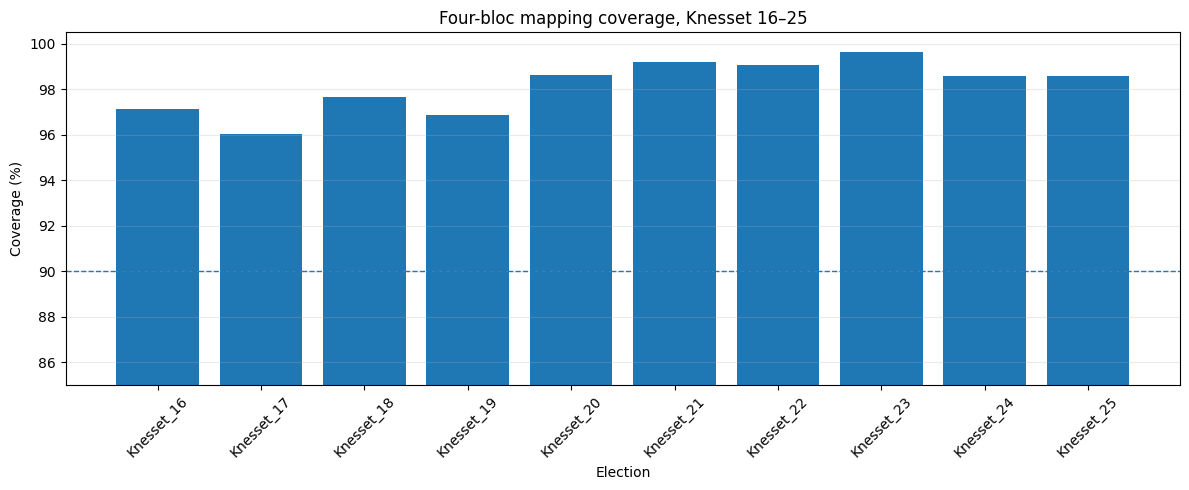

Figure saved to: /content/Election_Bloc_Prediction_Project/reports/figures/election_mapping_coverage.png


In [10]:
if len(election_coverage_summary) != 10:
    raise RuntimeError(
        "Coverage figure cannot be created: "
        "the summary does not contain ten elections."
    )

figure_path = (
    FIGURES_DIR
    / "election_mapping_coverage.png"
)

figure, axis = plt.subplots(
    figsize=(12, 5)
)

axis.bar(
    election_coverage_summary[
        "target_election"
    ],
    election_coverage_summary[
        "modeled_vote_coverage_pct"
    ],
)

axis.axhline(
    MINIMUM_TOTAL_MAPPING_COVERAGE_PCT,
    linestyle="--",
    linewidth=1,
)

axis.set_title(
    "Four-bloc mapping coverage, Knesset 16–25"
)

axis.set_xlabel("Election")
axis.set_ylabel("Coverage (%)")
axis.set_ylim(85, 100.5)
axis.tick_params(axis="x", rotation=45)
axis.grid(axis="y", alpha=0.25)

figure.tight_layout()

figure.savefig(
    figure_path,
    dpi=160,
    bbox_inches="tight",
)

plt.show()

print("Figure saved to:", figure_path)

## 8. Save all outputs

In [11]:
OUTPUT_PATHS = {
    "election_bloc_results": (
        INTERIM_DIR
        / "election_bloc_results.csv"
    ),
    "party_mapping": (
        TABLES_DIR
        / "party_mapping_long.csv"
    ),
    "mapping_audit": (
        TABLES_DIR
        / "election_mapping_audit.csv"
    ),
    "coverage_summary": (
        TABLES_DIR
        / "election_coverage_summary.csv"
    ),
    "k17_crosswalk": (
        TABLES_DIR
        / "k17_locality_crosswalk_audit.csv"
    ),
    "excluded_special_rows": (
        TABLES_DIR
        / "excluded_special_rows.csv"
    ),
    "source_inventory": (
        TABLES_DIR
        / "raw_election_source_inventory.csv"
    ),
    "raw_read_audit": (
        TABLES_DIR
        / "raw_election_read_audit.csv"
    ),
    "raw_party_reconstruction_audit": (
        TABLES_DIR
        / "raw_party_reconstruction_audit.csv"
    ),
    "quality_checks": (
        TABLES_DIR
        / "notebook_01_quality_checks.csv"
    ),
    "coverage_figure": figure_path,
    "summary": (
        SUMMARIES_DIR
        / "notebook_01_summary.json"
    ),
}

election_bloc_results.to_csv(
    OUTPUT_PATHS["election_bloc_results"],
    index=False,
    encoding="utf-8-sig",
)

party_mapping.to_csv(
    OUTPUT_PATHS["party_mapping"],
    index=False,
    encoding="utf-8-sig",
)

election_mapping_audit.to_csv(
    OUTPUT_PATHS["mapping_audit"],
    index=False,
    encoding="utf-8-sig",
)

election_coverage_summary.to_csv(
    OUTPUT_PATHS["coverage_summary"],
    index=False,
    encoding="utf-8-sig",
)

k17_locality_crosswalk_audit.to_csv(
    OUTPUT_PATHS["k17_crosswalk"],
    index=False,
    encoding="utf-8-sig",
)

excluded_special_rows.to_csv(
    OUTPUT_PATHS["excluded_special_rows"],
    index=False,
    encoding="utf-8-sig",
)

election_source_inventory.to_csv(
    OUTPUT_PATHS["source_inventory"],
    index=False,
    encoding="utf-8-sig",
)

raw_election_read_audit.to_csv(
    OUTPUT_PATHS["raw_read_audit"],
    index=False,
    encoding="utf-8-sig",
)

raw_party_reconstruction_audit.to_csv(
    OUTPUT_PATHS["raw_party_reconstruction_audit"],
    index=False,
    encoding="utf-8-sig",
)

notebook_01_quality_checks.to_csv(
    OUTPUT_PATHS["quality_checks"],
    index=False,
    encoding="utf-8-sig",
)

summary = {
    "notebook": "01_data_loading_and_party_mapping",
    "created_at_utc": time.strftime(
        "%Y-%m-%dT%H:%M:%SZ",
        time.gmtime(),
    ),
    "trusted_input": "data/raw/Election_data",
    "elections_processed": available_elections,
    "rows_created": int(
        len(election_bloc_results)
    ),
    "unique_localities_across_all_elections": int(
        election_bloc_results[
            "locality_symbol"
        ].nunique()
    ),
    "main_blocs": MODELED_BLOCS,
    "largest_single_unmapped_party_pct": (
        largest_single_unmapped_party
    ),
    "minimum_total_mapping_coverage_pct": (
        minimum_total_mapping_coverage
    ),
    "maximum_composition_error": (
        maximum_composition_error
    ),
    "maximum_vote_reconstruction_error": (
        maximum_vote_reconstruction_error
    ),
    "k17_unresolved_regular_localities": (
        len(unresolved_regular_k17)
    ),
    "all_quality_checks_passed": bool(
        notebook_01_quality_checks[
            "passed"
        ].all()
    ),
    "outputs": {
        name: str(path.relative_to(REPO_ROOT))
        for name, path in OUTPUT_PATHS.items()
        if name != "summary"
    },
}

OUTPUT_PATHS["summary"].write_text(
    json.dumps(
        summary,
        ensure_ascii=False,
        indent=2,
    ),
    encoding="utf-8",
)

output_audit = pd.DataFrame([
    {
        "output": name,
        "relative_path": str(
            path.relative_to(REPO_ROOT)
        ),
        "exists": path.exists(),
        "size_bytes": (
            path.stat().st_size
            if path.exists()
            else 0
        ),
    }
    for name, path in OUTPUT_PATHS.items()
])

display(output_audit)

bad_outputs = output_audit.loc[
    ~output_audit["exists"]
    | output_audit["size_bytes"].le(0)
]

if not bad_outputs.empty:
    raise RuntimeError(
        "Missing or empty Notebook 01 outputs:\n"
        + bad_outputs.to_string(index=False)
    )

saved_results = pd.read_csv(
    OUTPUT_PATHS["election_bloc_results"],
    low_memory=False,
)

saved_elections = sorted(
    saved_results[
        "election_number"
    ].astype(int).unique().tolist()
)

print("Elections in saved CSV:", saved_elections)

if saved_elections != list(range(16, 26)):
    raise RuntimeError(
        "The saved output does not contain elections 16–25."
    )

print("All Notebook 01 files were saved successfully.")

,output,relative_path,exists,size_bytes
0,election_bloc_results,data/interim/election_bloc_results.csv,True,3744326
1,party_mapping,reports/tables/party_mapping_long.csv,True,7536
2,mapping_audit,reports/tables/election_mapping_audit.csv,True,22236
3,coverage_summary,reports/tables/election_coverage_summary.csv,True,1879
4,k17_crosswalk,reports/tables/k17_locality_crosswalk_audit.csv,True,66579
5,excluded_special_rows,reports/tables/excluded_special_rows.csv,True,28016
6,source_inventory,reports/tables/raw_election_source_inventory.csv,True,1626
7,raw_read_audit,reports/tables/raw_election_read_audit.csv,True,355
8,raw_party_reconstruction_audit,reports/tables/raw_party_reconstruction_audit.csv,True,116
9,quality_checks,reports/tables/notebook_01_quality_checks.csv,True,613


Elections in saved CSV: [16, 17, 18, 19, 20, 21, 22, 23, 24, 25]
All Notebook 01 files were saved successfully.


## 9. Download a verified ZIP

In [12]:
ZIP_PATH = Path(
    "/content/notebook_01_outputs.zip"
)

if ZIP_PATH.exists():
    ZIP_PATH.unlink()

with ZipFile(
    ZIP_PATH,
    mode="w",
    compression=ZIP_DEFLATED,
) as zip_file:
    for path in OUTPUT_PATHS.values():
        zip_file.write(
            path,
            arcname=str(
                path.relative_to(REPO_ROOT)
            ),
        )

with ZipFile(
    ZIP_PATH,
    mode="r",
) as zip_file:
    zipped_files = zip_file.namelist()

    empty_zip_members = [
        filename
        for filename in zipped_files
        if zip_file.getinfo(filename).file_size <= 0
    ]

print("ZIP path:", ZIP_PATH)
print("ZIP size:", ZIP_PATH.stat().st_size, "bytes")
print("\nFiles inside ZIP:")

for filename in zipped_files:
    print("-", filename)

if len(zipped_files) != len(OUTPUT_PATHS):
    raise RuntimeError(
        "The ZIP does not contain every expected output."
    )

if empty_zip_members:
    raise RuntimeError(
        "The ZIP contains empty files:\n- "
        + "\n- ".join(empty_zip_members)
    )

from google.colab import files
files.download(str(ZIP_PATH))

ZIP path: /content/notebook_01_outputs.zip
ZIP size: 1352643 bytes

Files inside ZIP:
- data/interim/election_bloc_results.csv
- reports/tables/party_mapping_long.csv
- reports/tables/election_mapping_audit.csv
- reports/tables/election_coverage_summary.csv
- reports/tables/k17_locality_crosswalk_audit.csv
- reports/tables/excluded_special_rows.csv
- reports/tables/raw_election_source_inventory.csv
- reports/tables/raw_election_read_audit.csv
- reports/tables/raw_party_reconstruction_audit.csv
- reports/tables/notebook_01_quality_checks.csv
- reports/figures/election_mapping_coverage.png
- reports/summaries/notebook_01_summary.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Completion criteria

Notebook 01 is complete only when all of the following appear:

```text
Raw elections loaded: [16, 17, 18, 19, 20, 21, 22, 23, 24, 25]
All Notebook 01 quality checks passed.
Elections in saved CSV: [16, 17, 18, 19, 20, 21, 22, 23, 24, 25]
```

The coverage chart must show **ten bars**, from `Knesset_16` through `Knesset_25`.

The central input for Notebook 02 is:

```text
data/interim/election_bloc_results.csv
```